# Qamel / Timing-Multiuser-Protocols — Publication Figures

This notebook produces every paper figure from **whatever data currently exists** in the
repository's `qamel/outputs/` tree, plus the analytical baselines in `analytical_solution/`.

**Ground rules baked into this notebook**

1. *Verify, don't assume.* Column names, JSON keys and analytical signatures were read off the
   real files, not the README / `CODEBASE_OVERVIEW.tex` (which disagree with the code in places).
2. *Never fabricate.* Where a data source for a figure is missing, the cell prints exactly which
   file/run is absent and the command that would produce it, then draws a clearly-labelled
   placeholder instead of inventing numbers.
3. *Single seed is the current reality.* All runs use seed `12345`. Aggregation code globs over
   seeds and would draw mean ± IQR bands if more than one were present; with one seed it plots the
   single trace and stamps the figure **"single seed (12345) — multi-seed bands pending"**.
4. *The schematic is a first draft* meant to be refined by hand.

Run it top-to-bottom with the **`physics-env`** kernel (it has `matplotlib`, `torch`, `pandas`,
`scipy`, `rich`). Figures are written to `figures/` as both vector PDF and 300-dpi PNG.

## 0. Setup — paths, imports, repo-root discovery

We anchor every path to the repository root (the directory that contains both `qamel/outputs`
and `analytical_solution`), discovered by walking up from the current working directory. This
makes the notebook runnable from `notebooks/` (the usual case) or from the repo root.

In [1]:
import os, sys, json, glob, warnings, shutil, io, re
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")  # torch<->numpy ABI chatter in this env is harmless

def find_repo_root(start: Path) -> Path:
    start = Path(start).resolve()
    for cand in [start, *start.parents]:
        if (cand / "qamel" / "outputs").exists() and (cand / "analytical_solution").exists():
            return cand
    return start

REPO_ROOT = find_repo_root(Path.cwd())
OUTPUTS   = REPO_ROOT / "qamel" / "outputs"
STUDIES   = OUTPUTS / "studies"
RUNS      = OUTPUTS / "runs"
FIGDIR    = REPO_ROOT / "figures"
FIGDIR.mkdir(exist_ok=True)

# Make analytical_solution importable.
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repo root :", REPO_ROOT)
print("Outputs   :", OUTPUTS, "(exists:", OUTPUTS.exists(), ")")
print("Figures   :", FIGDIR)

Repo root : /Users/idilgozel/Timing-Multiuser-Protocols
Outputs   : /Users/idilgozel/Timing-Multiuser-Protocols/qamel/outputs (exists: True )
Figures   : /Users/idilgozel/Timing-Multiuser-Protocols/figures


## 1. Shared style + `save_fig` helper

One colourblind-safe palette (Okabe–Ito), serif math text, no chartjunk, tight layout. LaTeX
text rendering is enabled **only if a real `latex` render succeeds** — otherwise we fall back to
matplotlib's mathtext so the notebook never hangs on a missing TeX package.

`save_fig(fig, name)` writes both `figures/<name>.pdf` (vector) and `figures/<name>.png` (300 dpi).
`single_seed_stamp(ax)` adds the mandated single-seed annotation.

In [2]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Okabe-Ito colourblind-safe palette
OKABE_ITO = {
    "black":     "#000000",
    "orange":    "#E69F00",
    "skyblue":   "#56B4E9",
    "green":     "#009E73",
    "yellow":    "#F0E442",
    "blue":      "#0072B2",
    "vermillion":"#D55E00",
    "purple":    "#CC79A7",
}
PALETTE = list(OKABE_ITO.values())

def _latex_renders() -> bool:
    # True only if matplotlib can actually drive latex to render a label.
    if shutil.which("latex") is None:
        return False
    try:
        with matplotlib.rc_context({
            "text.usetex": True,
            "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}",
        }):
            fig, ax = plt.subplots(figsize=(1, 1))
            ax.set_title(r"$\mathbb{R}^{3}\;x^2$")  # exercise amssymb + super/subscripts
            buf = io.BytesIO()
            fig.savefig(buf, format="png")
            plt.close(fig)
        return True
    except Exception:
        return False

USE_TEX = _latex_renders()
if USE_TEX:
    # amssymb/amsmath are needed for \mathbb, \mathrm etc. used in the figure labels.
    rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amssymb}"

rcParams.update({
    "text.usetex":        USE_TEX,
    "font.family":        "serif",
    "font.serif":         ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset":   "cm",
    "font.size":          11,
    "axes.titlesize":     12,
    "axes.labelsize":     11,
    "legend.fontsize":    9.5,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.25,
    "grid.linewidth":     0.6,
    "axes.axisbelow":     True,
    "figure.dpi":         110,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.03,
    "axes.prop_cycle":    plt.cycler(color=PALETTE),
})
print("LaTeX text rendering:", "ON" if USE_TEX else "OFF (mathtext fallback)")

def save_fig(fig, name: str):
    pdf = FIGDIR / f"{name}.pdf"
    png = FIGDIR / f"{name}.png"
    fig.savefig(pdf)
    fig.savefig(png, dpi=300)
    print(f"saved -> {pdf.relative_to(REPO_ROOT)}  &  {png.relative_to(REPO_ROOT)}")

def pct(x, decimals=0):
    # usetex-safe percentage string ('%' is a comment char under LaTeX).
    s = f"{x*100:.{decimals}f}"
    return s + (r"\%" if USE_TEX else "%")

def single_seed_stamp(ax, text="single seed (12345) - multi-seed bands pending"):
    ax.text(0.99, 0.01, text, transform=ax.transAxes, ha="right", va="bottom",
            fontsize=7.5, style="italic", color=OKABE_ITO["vermillion"], alpha=0.9)

def missing_panel(ax, title, msg):
    # Render a clearly-labelled placeholder for a missing data source.
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0.02, 0.02), 0.96, 0.96, transform=ax.transAxes,
                               fill=False, ls="--", lw=1.2, ec=OKABE_ITO["vermillion"]))
    ax.text(0.5, 0.62, "DATA MISSING", transform=ax.transAxes, ha="center",
            fontsize=14, weight="bold", color=OKABE_ITO["vermillion"])
    ax.text(0.5, 0.40, msg, transform=ax.transAxes, ha="center", va="center",
            fontsize=8.5, wrap=True, family="monospace")
    ax.set_title(title)

LaTeX text rendering: ON


## First cell deliverable — DATA INVENTORY

Before any plotting we scan the outputs tree and print, at a glance, what each figure can and
cannot use: which study directories exist, which budgets they archived, how many evaluation
summaries and per-episode count files are present, and how many distinct seeds appear.

In [3]:
def read_json(p):
    try:
        with open(p) as fh: return json.load(fh)
    except Exception:
        return {}

# ---- studies ----
study_rows = []
for study_dir in sorted(STUDIES.glob("*")):
    if not study_dir.is_dir():
        continue
    budgets = sorted(int(b.name.split("_")[1]) for b in study_dir.glob("budget_*") if b.is_dir())
    cbs = study_dir / "cross_budget_summary.csv"
    # infer n / seed / pgen / pswap from any budget config
    n = seed = pgen = pswap = None
    cfgs = list(study_dir.glob("budget_*/config.json"))
    if cfgs:
        c = read_json(cfgs[0])
        n    = c.get("env", {}).get("n")
        pgen = c.get("env", {}).get("pgen")
        pswap= c.get("env", {}).get("pswap")
        seed = c.get("train", {}).get("seed")
    study_rows.append({
        "study": study_dir.name, "n": n, "seed": seed,
        "pgen": pgen, "pswap": pswap,
        "budgets": ",".join(map(str, budgets)) if budgets else "-",
        "cross_budget_csv": cbs.exists(),
        "diagnostics": (study_dir / "diagnostics").exists(),
    })
studies_df = pd.DataFrame(study_rows)

# ---- runs (evaluation artifacts) ----
def count_words(p):
    try:    return len(Path(p).read_text().split())
    except Exception: return 0

run_rows = []
for run_dir in sorted(RUNS.glob("dqn_*")):
    m = re.match(r"dqn_n(\d+)_", run_dir.name)
    n = int(m.group(1)) if m else None
    evald = run_dir / "evaluations"
    summaries = list(evald.glob("*_summary.json")) if evald.exists() else []
    ent  = list(evald.glob("*_ent_counts.txt"))  if evald.exists() else []
    swp  = list(evald.glob("*_swap_counts.txt")) if evald.exists() else []
    best_sr = None
    for s in summaries:
        d = read_json(s)
        if "success_rate" in d:
            best_sr = d["success_rate"] if best_sr is None else max(best_sr, d["success_rate"])
    run_rows.append({
        "run": run_dir.name, "n": n,
        "n_eval_summaries": len(summaries),
        "ent_count_files": len(ent),
        "max_ent_samples": max([count_words(p) for p in ent], default=0),
        "best_success_rate": best_sr,
    })
runs_df = pd.DataFrame(run_rows)

# ---- seeds present overall ----
seeds = sorted({r["seed"] for r in study_rows if r["seed"] is not None})

print("=" * 78)
print("STUDIES (budget-sweep archives)")
print("=" * 78)
with pd.option_context("display.max_rows", None, "display.width", 200):
    print(studies_df.to_string(index=False))

print("\n" + "=" * 78)
print(f"RUNS with evaluation artifacts  (n values present: "
      f"{sorted(set(r['n'] for r in run_rows if r['n'] is not None))})")
print("=" * 78)
nonempty = runs_df[runs_df["n_eval_summaries"] > 0].sort_values(
    ["n", "best_success_rate"], ascending=[True, False])
with pd.option_context("display.max_rows", None, "display.width", 220):
    print(nonempty.to_string(index=False))

print("\n" + "=" * 78)
print("HEADLINE GAPS")
print("=" * 78)
print(f"  distinct seeds across studies : {seeds or 'unknown'}  -> single-seed regime")
n_values = sorted(set(r['n'] for r in run_rows if r['n'] is not None))
print(f"  chain sizes with any run      : {n_values}")
print(f"  n=6 runs present              : {'YES' if 6 in n_values else 'NO  (README claims in-progress; Figs 2/3 n=6 BLOCKED)'}")
print(f"  budgets in studies            : "
      f"{sorted({b for r in study_rows for b in (r['budgets'].split(',') if r['budgets']!='-' else [])}, key=lambda x:int(x))}")
print( "  NOTE: canonical 10k/50k/100k/200k budgets were never archived locally;")
print( "        only local-pilot budgets (50/200/500/1000) exist -> RL is under-trained.")

STUDIES (budget-sweep archives)
                   study  n  seed  pgen  pswap         budgets  cross_budget_csv  diagnostics
 cpu_swapaware_seed12345  5 12345   0.4    0.7      50,200,500              True        False
lq_seed12345_progressive  5 12345   0.4    0.7 50,200,500,1000              True         True
  swapaware_driver_smoke  5 12345   0.4    0.7               1              True        False

RUNS with evaluation artifacts  (n values present: [3, 5])
                                                                   run  n  n_eval_summaries  ent_count_files  max_ent_samples  best_success_rate
                                    dqn_n3_pgen0.4_pswap0.7_quick_test  3                 1                1              200              1.000
  dqn_n5_pgen0.4_pswap0.7_lq_seed12345_progressive_ckpt1000_swapprefer  5                 1                1              500              0.680
  dqn_n5_pgen0.4_pswap0.7_lq_seed12345_progressive_ckpt0700_swapprefer  5                 1      

## Canonical settings used throughout

These are read off the real configs (`n=5`, `pgen=0.4`, `pswap=0.7`, `seed=12345`). The
analytical baselines use the **segment** convention; the mapping to the RL **node** convention is
`n_segments = n_nodes - 1`, stated again in the centerpiece figure.

In [4]:
N_NODES   = 5
N_SEGMENTS = N_NODES - 1     # 4 segments = 2^2 (a clean power of two -> generate_tpm is happy)
PGEN      = 0.4
PSWAP     = 0.7
PFUSION   = 0.5              # only used by the latency / Monte-Carlo grid model
SEED      = 12345

# Primary n=5 study (richest diagnostics) and its companions.
PRIMARY_STUDY = STUDIES / "lq_seed12345_progressive"
print("Primary study exists:", PRIMARY_STUDY.exists(), "->", PRIMARY_STUDY.name)

Primary study exists: True -> lq_seed12345_progressive


## Figure 1 — System / MDP schematic

**What it shows.** A programmatic first-draft diagram of the 1-D repeater chain the RL agent
actually controls (elementary nearest-neighbour links + interior swaps), plus an annotated panel
of the `(3, n, n)` state tensor and the action encoding.

**Data source.** None — this is a structural diagram derived from `qamel/environment.py` and
`qamel/utils.py` (the real implemented dynamics, not the broader OFC-paper grid scope).

**Takeaway (one sentence).** The learned problem is bipartite end-to-end Bell-pair scheduling on
an `n`-node chain, with a 3-channel state (adjacency + diagonal generation/swap counters) and a
matrix action whose one-off-diagonals request generation and whose main diagonal requests swaps.

saved -> figures/fig1_schematic.pdf  &  figures/fig1_schematic.png


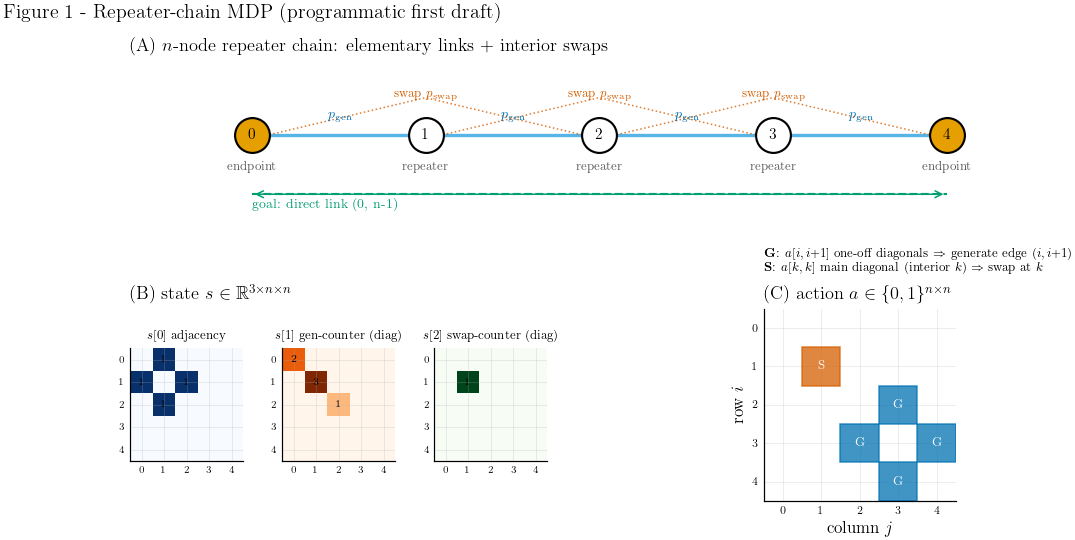

In [5]:
def draw_schematic(n=5):
    fig = plt.figure(figsize=(11, 5.2))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.15], width_ratios=[1.0, 1.0],
                          hspace=0.45, wspace=0.25)

    # ---- (A) the chain ----
    axc = fig.add_subplot(gs[0, :])
    axc.set_title("(A) $n$-node repeater chain: elementary links + interior swaps", loc="left")
    xs = np.arange(n)
    ys = np.zeros(n)
    # elementary links
    for i in range(n - 1):
        axc.plot([xs[i], xs[i+1]], [0, 0], color=OKABE_ITO["skyblue"], lw=2.2, zorder=1)
        axc.text((xs[i]+xs[i+1])/2, 0.13, r"$p_{\mathrm{gen}}$", ha="center",
                 color=OKABE_ITO["blue"], fontsize=9)
    # nodes
    for i in range(n):
        endpoint = i in (0, n-1)
        axc.scatter([xs[i]], [0], s=520,
                    color=(OKABE_ITO["orange"] if endpoint else "white"),
                    edgecolor=OKABE_ITO["black"], zorder=3, linewidths=1.4)
        axc.text(xs[i], 0, str(i), ha="center", va="center", fontsize=10, zorder=4)
        role = "endpoint" if endpoint else "repeater"
        axc.text(xs[i], -0.22, role, ha="center", va="top", fontsize=8, color="0.35")
    # swap arcs on interior nodes
    for k in range(1, n-1):
        axc.annotate("", xy=(k+0.0, 0.34), xytext=(k-0.0, 0.34),
                     arrowprops=dict(arrowstyle="-"))
        axc.annotate(r"swap $p_{\mathrm{swap}}$", xy=(k, 0.30), ha="center",
                     fontsize=8, color=OKABE_ITO["vermillion"])
        axc.plot([k-0.9, k, k+0.9], [0.0, 0.30, 0.0], color=OKABE_ITO["vermillion"],
                 lw=1.0, ls=":", alpha=0.8)
    axc.annotate("goal: direct link (0, n-1)", xy=(0, 0), xytext=(0, -0.6),
                 fontsize=8.5, color=OKABE_ITO["green"])
    axc.plot([0, n-1], [-0.48, -0.48], color=OKABE_ITO["green"], lw=1.4, ls="--")
    axc.annotate("", xy=(n-1, -0.48), xytext=(0, -0.48),
                 arrowprops=dict(arrowstyle="<->", color=OKABE_ITO["green"], lw=1.0))
    axc.set_xlim(-0.7, n-0.3); axc.set_ylim(-0.75, 0.6)
    axc.axis("off")

    # ---- (B) state tensor (3, n, n) ----
    axs = fig.add_subplot(gs[1, 0])
    axs.set_title(r"(B) state $s \in \mathbb{R}^{3\times n\times n}$", loc="left")
    # toy state: links (0,1) and (1,2) up
    adj = np.zeros((n, n)); adj[0,1]=adj[1,0]=1; adj[1,2]=adj[2,1]=1
    gen = np.diag([2,3,1,0,0]).astype(float)
    swp = np.diag([0,1,0,0,0]).astype(float)
    chans = [("$s[0]$ adjacency", adj, "Blues"),
             ("$s[1]$ gen-counter (diag)", gen, "Oranges"),
             ("$s[2]$ swap-counter (diag)", swp, "Greens")]
    sub = gs[1, 0].subgridspec(1, 3, wspace=0.35)
    axs.axis("off")
    for j, (title, mat, cmap) in enumerate(chans):
        a = fig.add_subplot(sub[0, j])
        a.imshow(mat, cmap=cmap, vmin=0, vmax=max(1, mat.max()))
        a.set_title(title, fontsize=8)
        a.set_xticks(range(n)); a.set_yticks(range(n))
        a.tick_params(length=0, labelsize=6)
        for (yy, xx), v in np.ndenumerate(mat):
            if v: a.text(xx, yy, int(v), ha="center", va="center", fontsize=6.5)

    # ---- (C) action encoding (n, n) ----
    axa = fig.add_subplot(gs[1, 1])
    axa.set_title(r"(C) action $a \in \{0,1\}^{n\times n}$", loc="left")
    act = np.zeros((n, n))
    # generation requests on one-offset diagonals
    act[2,3]=act[3,2]=1; act[3,4]=act[4,3]=1
    # swap request on interior diagonal
    act[1,1]=1
    axa.imshow(np.zeros((n,n)), cmap="Greys", vmin=0, vmax=1)
    for (yy, xx), v in np.ndenumerate(act):
        if v == 0: continue
        is_swap = (xx == yy)
        col = OKABE_ITO["vermillion"] if is_swap else OKABE_ITO["blue"]
        axa.add_patch(plt.Rectangle((xx-0.5, yy-0.5), 1, 1, color=col, alpha=0.75))
        axa.text(xx, yy, "S" if is_swap else "G", ha="center", va="center",
                 color="white", fontsize=8, weight="bold")
    axa.set_xticks(range(n)); axa.set_yticks(range(n)); axa.tick_params(length=0, labelsize=7)
    axa.set_xlabel("column $j$"); axa.set_ylabel("row $i$")
    axa.text(0.0, 1.18,
             r"$\mathbf{G}$: $a[i,i{+}1]$ one-off diagonals $\Rightarrow$ generate edge $(i,i{+}1)$"
             "\n"
             r"$\mathbf{S}$: $a[k,k]$ main diagonal (interior $k$) $\Rightarrow$ swap at $k$",
             transform=axa.transAxes, fontsize=8, va="bottom")

    fig.suptitle("Figure 1 - Repeater-chain MDP (programmatic first draft)", x=0.02, ha="left",
                 fontsize=13)
    return fig

fig = draw_schematic(N_NODES)
save_fig(fig, "fig1_schematic")
plt.show()

## Figure 2 — Learning curves

**What it shows.** Training-time success proxy and mean return vs episode for the n=5 study, read
from each run's `metrics.csv` (columns `success_proxy_window`, `avg_return_window`). We glob over
seeds; with one seed we draw the single trace and stamp it accordingly. Best-eval points from
`best_eval_metrics.json` are overlaid where present.

**Data source.** `qamel/outputs/studies/lq_seed12345_progressive/budget_*/metrics.csv` (largest
budget contains the full curve) and any `best_eval_metrics.json`.

**Takeaway (one sentence).** At the local-pilot budget (≤1000 episodes, single seed) the n=5 agent
is still in the noisy early-learning regime — convergence requires the larger budgets that have
not yet been archived; **n=6 has no runs at all**.

saved -> figures/fig2_learning_curves.pdf  &  figures/fig2_learning_curves.png


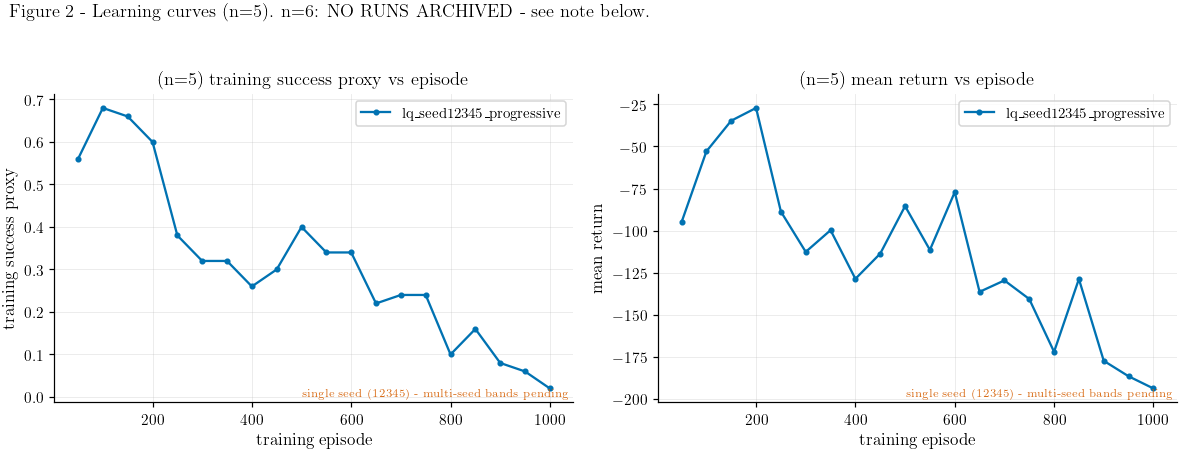

In [6]:
def load_learning_curve_for_study(study_dir):
    # Return the metrics.csv from the largest archived budget (the longest curve).
    budget_dirs = sorted(study_dir.glob("budget_*"),
                         key=lambda p: int(p.name.split("_")[1]))
    if not budget_dirs:
        return None, None
    biggest = budget_dirs[-1]
    mpath = biggest / "metrics.csv"
    if not mpath.exists():
        return None, None
    return pd.read_csv(mpath), int(biggest.name.split("_")[1])

def gather_n5_seed_curves():
    # Glob studies that are n=5; group by seed -> {seed: (df, budget, study_name)}.
    out = {}
    for study_dir in sorted(STUDIES.glob("*")):
        cfgs = list(study_dir.glob("budget_*/config.json"))
        if not cfgs:
            continue
        c = read_json(cfgs[0])
        if c.get("env", {}).get("n") != 5:
            continue
        seed = c.get("train", {}).get("seed")
        df, budget = load_learning_curve_for_study(study_dir)
        if df is None:
            continue
        # keep the study with the most episodes per seed
        if seed not in out or len(df) > len(out[seed][0]):
            out[seed] = (df, budget, study_dir.name)
    return out

curves = gather_n5_seed_curves()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
if not curves:
    for ax in axes:
        missing_panel(ax, "Learning curve", "No n=5 metrics.csv found under\nqamel/outputs/studies/*/budget_*/")
else:
    seeds_here = sorted(curves)
    multi = len(seeds_here) > 1
    for col, (metric, label) in enumerate(
            [("success_proxy_window", "training success proxy"),
             ("avg_return_window", "mean return")]):
        ax = axes[col]
        if multi:
            # align on episode, compute mean and IQR band across seeds
            merged = None
            for sd in seeds_here:
                df = curves[sd][0][["episode", metric]].set_index("episode")
                df.columns = [f"s{sd}"]
                merged = df if merged is None else merged.join(df, how="outer")
            merged = merged.sort_index().interpolate()
            mean = merged.mean(axis=1)
            q1, q3 = merged.quantile(0.25, axis=1), merged.quantile(0.75, axis=1)
            ax.plot(mean.index, mean.values, color=OKABE_ITO["blue"], label="mean over seeds")
            ax.fill_between(mean.index, q1.values, q3.values, color=OKABE_ITO["blue"],
                            alpha=0.2, label="IQR band")
        else:
            sd = seeds_here[0]
            df, budget, name = curves[sd]
            ax.plot(df["episode"], df[metric], marker="o", ms=3,
                    color=OKABE_ITO["blue"], label=f"{name}")
            single_seed_stamp(ax)
        ax.set_xlabel("training episode"); ax.set_ylabel(label)
        ax.set_title(f"(n=5)  {label} vs episode")
        ax.legend(loc="best")

fig.suptitle("Figure 2 - Learning curves (n=5).  n=6: NO RUNS ARCHIVED - see note below.",
             x=0.02, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_fig(fig, "fig2_learning_curves")
plt.show()

> **Blocked sub-panel — n=6 learning curve.** No `dqn_n6_*` run directory exists anywhere under
> `qamel/outputs/`. To produce it, run (per `BASELINE.md` / `scripts/run_stage2_study.sh`):
> ```bash
> N=6 PGEN=0.4 PSWAP=0.7 OBS_MODE=counter_exposed_plus_ready SEED=12345 \
> BUDGETS="10000 50000 100000 200000" RUN_TAG=n6_seed12345 \
> bash scripts/run_stage2_study.sh
> ```

## Figure 3 — Sample efficiency

**What it shows.** Evaluation success rate vs training budget (left) and mean steps-to-success
(right), from each study's `cross_budget_summary.csv` (columns verified:
`budget, success_rate, mean_return, mean_steps, mean_ent_attempt_max, mean_swap_attempt_max,
truncated_fraction`).

**Data source.** `qamel/outputs/studies/*/cross_budget_summary.csv`.

**Takeaway (one sentence).** The only archived budgets are the local-pilot values
(50/200/500/1000), at which n=5 success is low and non-monotone — i.e. these curves are a pipeline
demonstration, not the converged sample-efficiency result the paper needs.

saved -> figures/fig3_sample_efficiency.pdf  &  figures/fig3_sample_efficiency.png


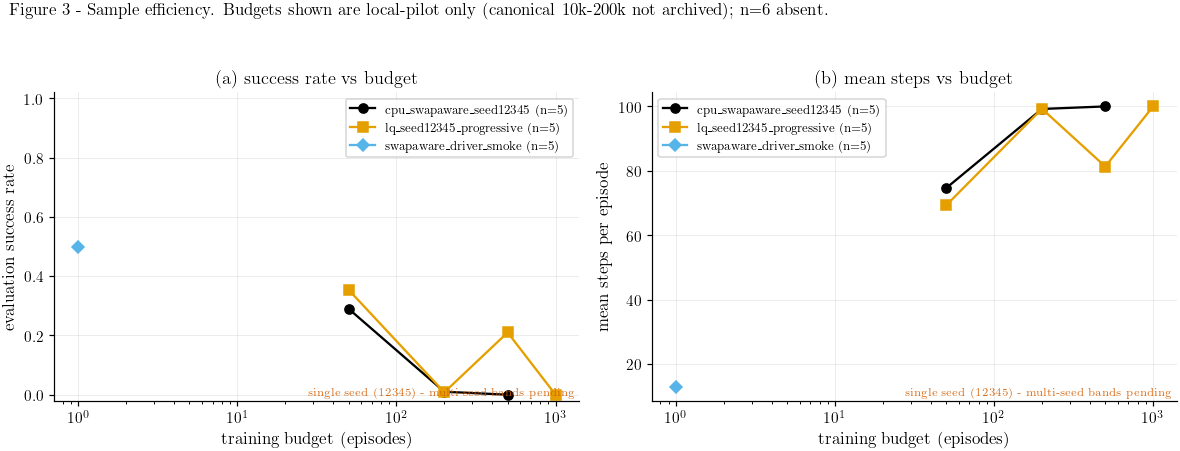

In [7]:
def load_cross_budget():
    rows = {}
    for cbs in STUDIES.glob("*/cross_budget_summary.csv"):
        study = cbs.parent.name
        cfgs = list(cbs.parent.glob("budget_*/config.json"))
        n = read_json(cfgs[0]).get("env", {}).get("n") if cfgs else None
        try:
            df = pd.read_csv(cbs).sort_values("budget")
        except Exception:
            continue
        rows[study] = (df, n)
    return rows

cb = load_cross_budget()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
if not cb:
    for ax in axes:
        missing_panel(ax, "Sample efficiency", "No cross_budget_summary.csv found")
else:
    markers = ["o", "s", "D", "^", "v"]
    for i, (study, (df, n)) in enumerate(sorted(cb.items())):
        c = PALETTE[i % len(PALETTE)]
        lab = f"{study} (n={n})"
        axes[0].plot(df["budget"], df["success_rate"], marker=markers[i % len(markers)],
                     color=c, label=lab)
        axes[1].plot(df["budget"], df["mean_steps"], marker=markers[i % len(markers)],
                     color=c, label=lab)
    axes[0].set_ylabel("evaluation success rate"); axes[0].set_ylim(-0.02, 1.02)
    axes[1].set_ylabel("mean steps per episode")
    for ax in axes:
        ax.set_xlabel("training budget (episodes)")
        ax.set_xscale("log")
        ax.legend(loc="best", fontsize=8)
        single_seed_stamp(ax)
    axes[0].set_title("(a) success rate vs budget")
    axes[1].set_title("(b) mean steps vs budget")

fig.suptitle("Figure 3 - Sample efficiency.  Budgets shown are local-pilot only "
             "(canonical 10k-200k not archived); n=6 absent.", x=0.02, ha="left", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_fig(fig, "fig3_sample_efficiency")
plt.show()

## Figure 4 — Attempt-count distributions vs analytical baseline  *(centerpiece)*

**What it shows.** Histograms of the learned policy's per-episode `ent_attempt_max` and
`swap_attempt_max` (one value per evaluation episode, from `*_ent_counts.txt` / `*_swap_counts.txt`)
with the analytical predictions overlaid at the matching `(n, pgen, pswap)`:
`bernardes_eq`, `shchukin_eq` (closed forms) and a Monte-Carlo sample (`MonteCarloFusion`).

**Convention mapping (important).** The analytical code counts **segments/distance**; the RL code
counts **nodes**. We use `n_segments = n_nodes − 1` → for n=5, **4 segments = 2² → nesting level 2**
(a clean power of two, which `generate_tpm`'s recursive Kronecker doubling requires).
Be careful: the RL quantities are a **per-node maximum** of attempt counters, while the analytical
quantities are **total generation rounds / total swaps** for the whole chain. These are *related
but not identical* — the overlay is a shape/scale reference, not an equality claim.

**Data source.** Best available greedy n=5 evaluation (selected by success rate from the checkpoint
sweep) + `analytical_solution/analytical_equations.py` + `analytical_solution/monte_carlo.py`.

**Takeaway (one sentence).** Against the closed-form optimum, the under-trained n=5 policy spends
far more generation attempts than necessary — the gap to `shchukin_eq` is the headroom the larger
training budgets are meant to close.

saved -> figures/fig4_attempt_distributions.pdf  &  figures/fig4_attempt_distributions.png


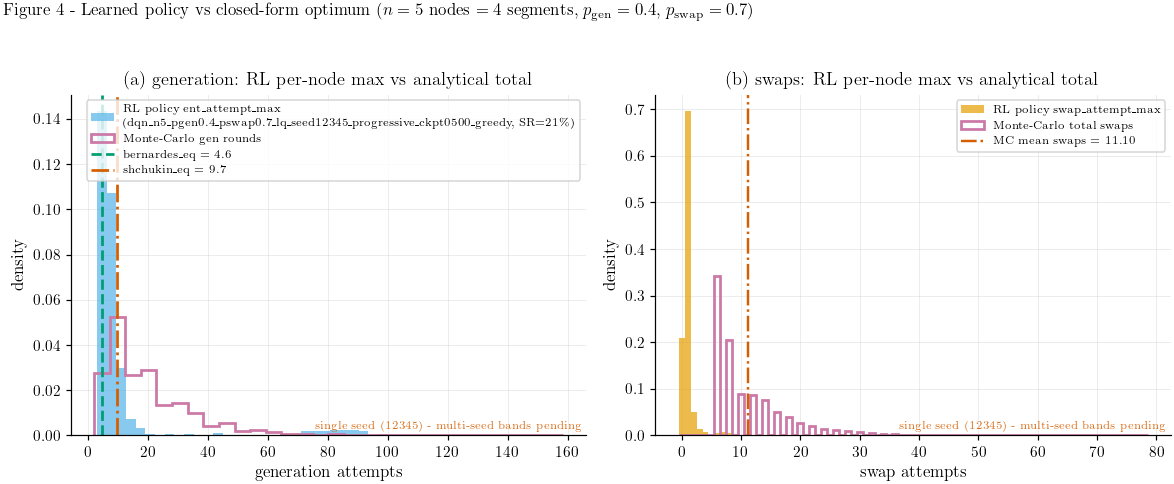

In [8]:
from analytical_solution.analytical_equations import bernardes_eq, shchukin_eq
from analytical_solution.monte_carlo import MonteCarloFusion

def select_best_greedy_eval():
    # Pick the n=5 greedy eval (>=100 episodes) with the highest success rate; return its
    # ent/swap count file paths and the summary dict, or None if none qualify.
    best = None
    for summ in RUNS.glob("dqn_n5_*greedy*/evaluations/*_summary.json"):
        d = read_json(summ)
        if d.get("eval_episodes", 0) < 100:
            continue
        ent = Path(str(summ).replace("_summary.json", "_ent_counts.txt"))
        swp = Path(str(summ).replace("_summary.json", "_swap_counts.txt"))
        if not (ent.exists() and swp.exists()):
            continue
        sr = d.get("success_rate", -1)
        if best is None or sr > best[0]:
            best = (sr, ent, swp, d, summ.parent.parent.name)
    return best

sel = select_best_greedy_eval()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
if sel is None:
    for ax in axes:
        missing_panel(ax, "Attempt-count distribution",
                      "No n=5 greedy eval with\n*_ent_counts.txt / *_swap_counts.txt found")
else:
    sr, ent_path, swp_path, summ, run_name = sel
    ent = np.loadtxt(ent_path)
    swp = np.loadtxt(swp_path)

    # ---- analytical references (segment convention) ----
    bern = bernardes_eq(N_SEGMENTS, PGEN)             # expected gen rounds, no swap retries
    shch = shchukin_eq(N_SEGMENTS, PGEN, PSWAP)        # expected gen attempts incl. swap restarts
    nesting = int(np.log2(N_SEGMENTS))                 # 4 segments -> level 2
    mc = MonteCarloFusion(nesting, PGEN, PSWAP, PFUSION)
    mc.sample(20000, 20000)
    mc_gen = np.asarray(mc.tp_samples)                 # total generation rounds (max over tree)
    mc_swp = np.asarray(mc.tq_samples)                 # total swap operations

    # ---- (a) generation attempts ----
    ax = axes[0]
    ax.hist(ent, bins=30, density=True, color=OKABE_ITO["skyblue"], alpha=0.7,
            label=f"RL policy ent\\_attempt\\_max\n({run_name}, SR={pct(sr)})" if USE_TEX
                  else f"RL policy ent_attempt_max\n({run_name}, SR={pct(sr)})")
    ax.hist(mc_gen, bins=30, density=True, histtype="step", lw=1.8,
            color=OKABE_ITO["purple"], label="Monte-Carlo gen rounds")
    ax.axvline(bern, color=OKABE_ITO["green"], lw=1.8, ls="--",
               label=f"bernardes\\_eq = {bern:.1f}" if USE_TEX else f"bernardes_eq = {bern:.1f}")
    ax.axvline(shch, color=OKABE_ITO["vermillion"], lw=1.8, ls="-.",
               label=f"shchukin\\_eq = {shch:.1f}" if USE_TEX else f"shchukin_eq = {shch:.1f}")
    ax.set_xlabel("generation attempts"); ax.set_ylabel("density")
    ax.set_title("(a) generation: RL per-node max vs analytical total")
    ax.legend(fontsize=7.5, loc="upper right")

    # ---- (b) swap attempts ----
    ax = axes[1]
    maxs = int(max(swp.max(), mc_swp.max())) + 1
    bins = np.arange(-0.5, maxs + 0.5, 1)
    ax.hist(swp, bins=bins, density=True, color=OKABE_ITO["orange"], alpha=0.7,
            label="RL policy swap\\_attempt\\_max" if USE_TEX else "RL policy swap_attempt_max")
    ax.hist(mc_swp, bins=bins, density=True, histtype="step", lw=1.8,
            color=OKABE_ITO["purple"], label="Monte-Carlo total swaps")
    ax.axvline(mc_swp.mean(), color=OKABE_ITO["vermillion"], lw=1.6, ls="-.",
               label=f"MC mean swaps = {mc_swp.mean():.2f}")
    ax.set_xlabel("swap attempts"); ax.set_ylabel("density")
    ax.set_title("(b) swaps: RL per-node max vs analytical total")
    ax.legend(fontsize=7.5, loc="upper right")

    for ax in axes:
        single_seed_stamp(ax)

fig.suptitle(r"Figure 4 - Learned policy vs closed-form optimum  "
             r"($n=5$ nodes $=4$ segments, $p_{\mathrm{gen}}=0.4$, $p_{\mathrm{swap}}=0.7$)",
             x=0.02, ha="left", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_fig(fig, "fig4_attempt_distributions")
plt.show()

## Figure 5 — Policy vs baselines

**What it shows.** The DQN greedy policy compared against (b) the analytical expectation and (c) a
heuristic baseline, on success rate, mean steps, and mean generation attempts.

**Which baselines were actually available vs computed:**
- **(a) Tabular Q-learning** — a trained Q-table exists at `qamel/q_table_storage/5_nodes.txt`,
  **but no evaluation summary was ever produced for it**, and re-running it requires the
  (known-buggy) `qamel/agent.py`. It is therefore reported as *not evaluated* rather than faked.
- **(b) Analytical expectation** — computed fresh from `shchukin_eq` / `bernardes_eq`.
- **(c) Heuristic** — reuses the **`prefer_swap_when_ready`** ablation (`swap_priority` variant) as
  the heuristic baseline; these eval summaries already exist in the study diagnostics.

**Data source.** `…/diagnostics/eval_ablations/combined_ablation_summary.csv` (DQN greedy =
`baseline`; heuristic = `swap_priority`) + analytical equations.

**Takeaway (one sentence).** The simple swap-when-ready heuristic already beats the under-trained
DQN greedy policy on success rate, underscoring that the current DQN result is budget-limited
rather than a ceiling.

saved -> figures/fig5_policy_vs_baselines.pdf  &  figures/fig5_policy_vs_baselines.png


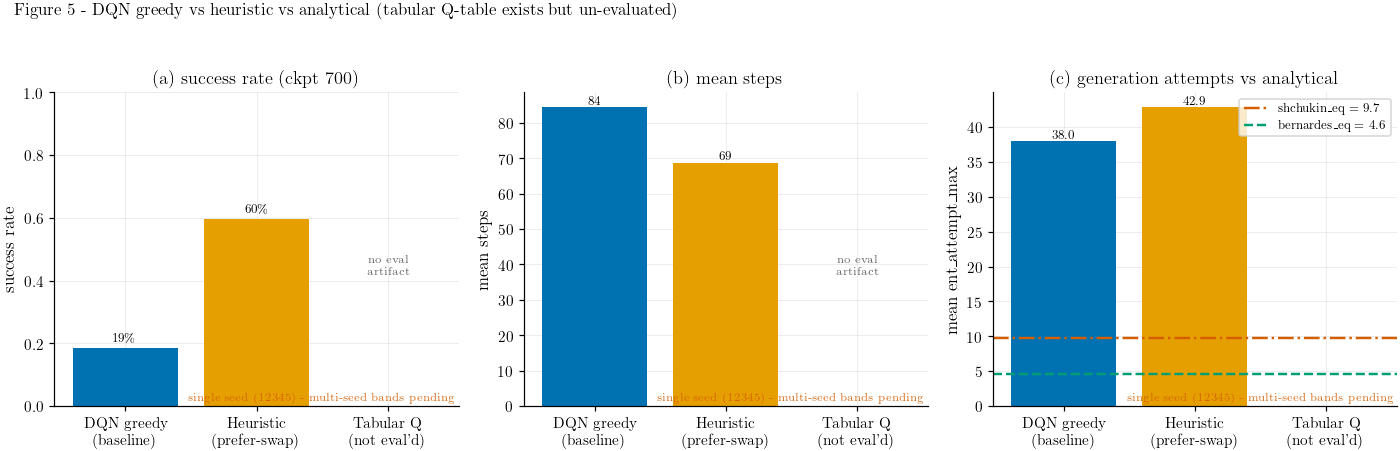

In [9]:
ABLATION_CSV = PRIMARY_STUDY / "diagnostics" / "eval_ablations" / "combined_ablation_summary.csv"

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
if not ABLATION_CSV.exists():
    for ax in axes:
        missing_panel(ax, "Policy vs baselines", f"missing\n{ABLATION_CSV.relative_to(REPO_ROOT)}")
else:
    abl = pd.read_csv(ABLATION_CSV)
    # use the best checkpoint available (max success in baseline variant)
    base = abl[abl["variant"] == "baseline"]
    best_ckpt = int(base.loc[base["success_rate"].idxmax(), "checkpoint"])
    sub = abl[abl["checkpoint"] == best_ckpt].set_index("variant")

    dqn = sub.loc["baseline"]
    heur = sub.loc["swap_priority"]

    bern = bernardes_eq(N_SEGMENTS, PGEN)
    shch = shchukin_eq(N_SEGMENTS, PGEN, PSWAP)

    labels = ["DQN greedy\n(baseline)", "Heuristic\n(prefer-swap)", "Tabular Q\n(not eval'd)"]
    colors = [OKABE_ITO["blue"], OKABE_ITO["orange"], "0.75"]

    # (a) success rate
    ax = axes[0]
    vals = [dqn["success_rate"], heur["success_rate"], np.nan]
    bars = ax.bar(labels, [v if np.isfinite(v) else 0 for v in vals], color=colors)
    ax.set_ylim(0, 1.0); ax.set_ylabel("success rate")
    ax.set_title(f"(a) success rate (ckpt {best_ckpt})")
    ax.text(2, 0.45, "no eval\nartifact", ha="center", va="center", fontsize=7.5,
            color="0.4", transform=ax.get_xaxis_transform())
    for b, v in zip(bars, vals):
        if np.isfinite(v): ax.text(b.get_x()+b.get_width()/2, v+0.02, pct(v), ha="center", fontsize=8)

    # (b) mean steps
    ax = axes[1]
    vals = [dqn["mean_steps"], heur["mean_steps"], np.nan]
    bars = ax.bar(labels, [v if np.isfinite(v) else 0 for v in vals], color=colors)
    ax.set_ylabel("mean steps"); ax.set_title("(b) mean steps")
    for b, v in zip(bars, vals):
        if np.isfinite(v): ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.0f}", ha="center", fontsize=8)
    ax.text(2, 0.45, "no eval\nartifact", ha="center", va="center", fontsize=7.5,
            color="0.4", transform=ax.get_xaxis_transform())

    # (c) mean generation attempts + analytical reference lines
    ax = axes[2]
    vals = [dqn["mean_ent_attempt_max"], heur["mean_ent_attempt_max"], np.nan]
    bars = ax.bar(labels, [v if np.isfinite(v) else 0 for v in vals], color=colors)
    ax.axhline(shch, color=OKABE_ITO["vermillion"], ls="-.", lw=1.6,
               label=f"shchukin_eq = {shch:.1f}")
    ax.axhline(bern, color=OKABE_ITO["green"], ls="--", lw=1.6,
               label=f"bernardes_eq = {bern:.1f}")
    ax.set_ylabel("mean ent_attempt_max")
    ax.set_title("(c) generation attempts vs analytical")
    ax.legend(fontsize=8)
    for b, v in zip(bars, vals):
        if np.isfinite(v): ax.text(b.get_x()+b.get_width()/2, v+0.5, f"{v:.1f}", ha="center", fontsize=8)

    for ax in axes:
        single_seed_stamp(ax)

fig.suptitle("Figure 5 - DQN greedy vs heuristic vs analytical (tabular Q-table exists but "
             "un-evaluated)", x=0.02, ha="left", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_fig(fig, "fig5_policy_vs_baselines")
plt.show()

## Figure 6 — Ablation deltas

**What it shows.** The effect of the three evaluation-time filters (`mask_null_action`,
`block_refresh_actions`, `prefer_swap_when_ready`) on success rate and mean steps, expressed as a
**delta vs the unfiltered baseline** at each checkpoint. A third panel surfaces
`ablation_empty_fallbacks` so any silently-ignored ablation (filter emptied the action set →
fell back to unfiltered) is visible.

**Data source.** `…/diagnostics/eval_ablations/combined_ablation_summary.csv` (the stage-A
diagnostics notebook's source of truth).

**Takeaway (one sentence).** `prefer_swap_when_ready` is by far the strongest lever (large positive
success delta, especially at later checkpoints), while `block_refresh_actions` is near-neutral —
and no ablation hit an empty-set fallback, so every reported delta is real.

saved -> figures/fig6_ablation_deltas.pdf  &  figures/fig6_ablation_deltas.png


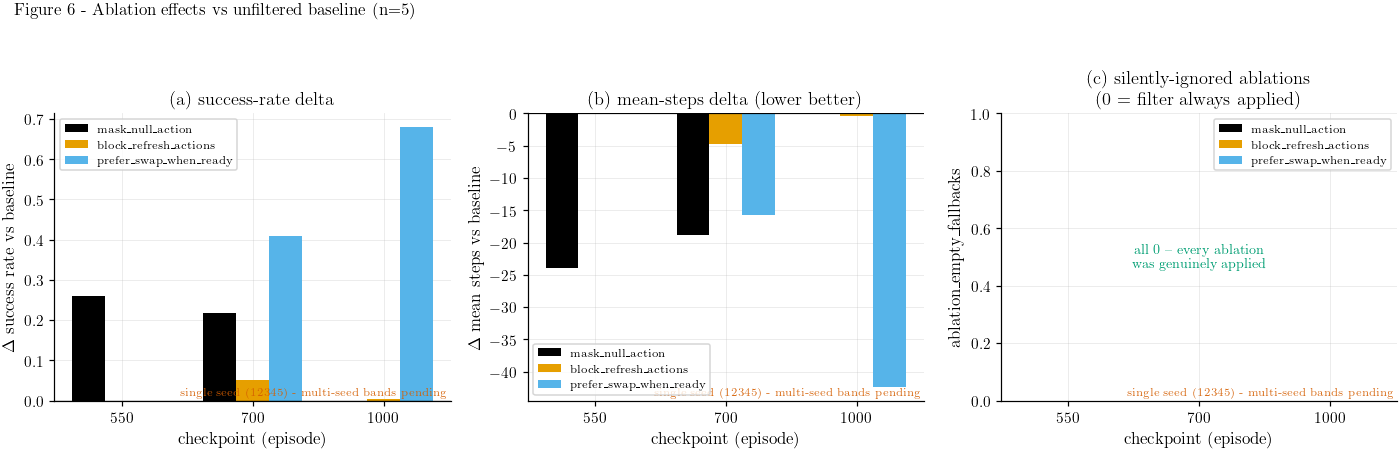

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
if not ABLATION_CSV.exists():
    for ax in axes:
        missing_panel(ax, "Ablation deltas", f"missing\n{ABLATION_CSV.relative_to(REPO_ROOT)}")
else:
    abl = pd.read_csv(ABLATION_CSV)
    variants = ["null_mask", "refresh_block", "swap_priority"]
    pretty = {"null_mask": "mask_null_action",
              "refresh_block": "block_refresh_actions",
              "swap_priority": "prefer_swap_when_ready"}
    ckpts = sorted(abl["checkpoint"].unique())
    base = abl[abl["variant"] == "baseline"].set_index("checkpoint")

    x = np.arange(len(ckpts)); w = 0.25
    # (a) success-rate delta
    ax = axes[0]
    for i, v in enumerate(variants):
        d = abl[abl["variant"] == v].set_index("checkpoint")
        delta = [d.loc[c, "success_rate"] - base.loc[c, "success_rate"] if c in d.index else np.nan
                 for c in ckpts]
        ax.bar(x + (i-1)*w, delta, w, color=PALETTE[i], label=pretty[v])
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(ckpts)
    ax.set_xlabel("checkpoint (episode)"); ax.set_ylabel(r"$\Delta$ success rate vs baseline")
    ax.set_title("(a) success-rate delta"); ax.legend(fontsize=7.5)

    # (b) mean-steps delta (negative = fewer steps = better)
    ax = axes[1]
    for i, v in enumerate(variants):
        d = abl[abl["variant"] == v].set_index("checkpoint")
        delta = [d.loc[c, "mean_steps"] - base.loc[c, "mean_steps"] if c in d.index else np.nan
                 for c in ckpts]
        ax.bar(x + (i-1)*w, delta, w, color=PALETTE[i], label=pretty[v])
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(ckpts)
    ax.set_xlabel("checkpoint (episode)"); ax.set_ylabel(r"$\Delta$ mean steps vs baseline")
    ax.set_title("(b) mean-steps delta (lower better)"); ax.legend(fontsize=7.5)

    # (c) empty-fallback counter
    ax = axes[2]
    for i, v in enumerate(variants):
        d = abl[abl["variant"] == v].set_index("checkpoint")
        fb = [d.loc[c, "ablation_empty_fallbacks"] if c in d.index else np.nan for c in ckpts]
        ax.bar(x + (i-1)*w, fb, w, color=PALETTE[i], label=pretty[v])
    ax.set_xticks(x); ax.set_xticklabels(ckpts)
    ax.set_xlabel("checkpoint (episode)"); ax.set_ylabel("ablation_empty_fallbacks")
    ax.set_title("(c) silently-ignored ablations\n(0 = filter always applied)")
    max_fb = np.nanmax(abl["ablation_empty_fallbacks"].values) if len(abl) else 0
    ax.set_ylim(0, max(1, max_fb * 1.2))
    if max_fb == 0:
        ax.text(0.5, 0.5, "all 0 -- every ablation\nwas genuinely applied", ha="center",
                va="center", transform=ax.transAxes, fontsize=9, color=OKABE_ITO["green"])
    ax.legend(fontsize=7.5, loc="upper right")

    for ax in axes:
        single_seed_stamp(ax)

fig.suptitle("Figure 6 - Ablation effects vs unfiltered baseline (n=5)", x=0.02, ha="left",
             fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_fig(fig, "fig6_ablation_deltas")
plt.show()

## Figure 7 — End-to-end latency vs n (classical / quantum breakdown)

**What it shows.** End-to-end latency as a function of chain/grid size, split into the **classical
communication** and **quantum operation** contributions, reusing the exact computation from
`notebooks/calculate_ratio_and_latencies.ipynb`.

**Physical assumptions (copied verbatim from that notebook).**
- swap success `q = 0.7`, fusion success `k = 0.5`;
- link-generation probability `p_l(L) = 0.0018 · 10^(−0.2·L/10)` (fibre attenuation, L in km);
- fibre signal speed `c = 299792.458 / 1.4585` km/s;
- fixed operation times `t_ent = 123 µs`, `t_swap = 2157 µs`, `t_fusion = 300 µs`;
- per Manhattan-distance grid model `monte_carlo(vertices, …)` from `analytical_solution`;
- classical contribution `= ε·(2·V·(L/c) + L/c) + σ·(2·(V−1)·(L/c))`,
  quantum contribution `= ε·t_ent + σ·t_swap + κ·t_ent`, with `(ε, σ, κ)` the mean
  generation/swap/fusion counts from the Monte-Carlo sampler.

**Data source.** `analytical_solution/monte_carlo.py` (logic mirrored from the existing latency
notebook). The **RL-derived** latency overlay (`qamel/outputs/results/qamel_results.txt`) is
**missing** (it was produced on a GPU box under a Windows path), so only the analytical/MC curve is
drawn and the RL overlay is flagged below.

**Takeaway (one sentence).** Under these assumptions the **classical signalling term dominates**
(≈58–76% of total latency) and its share grows with grid size, while the quantum-operation budget
plateaus once the nesting depth saturates — so end-to-end latency at scale is communication-bound,
not gate-bound.

saved -> figures/fig7_latency.pdf  &  figures/fig7_latency.png


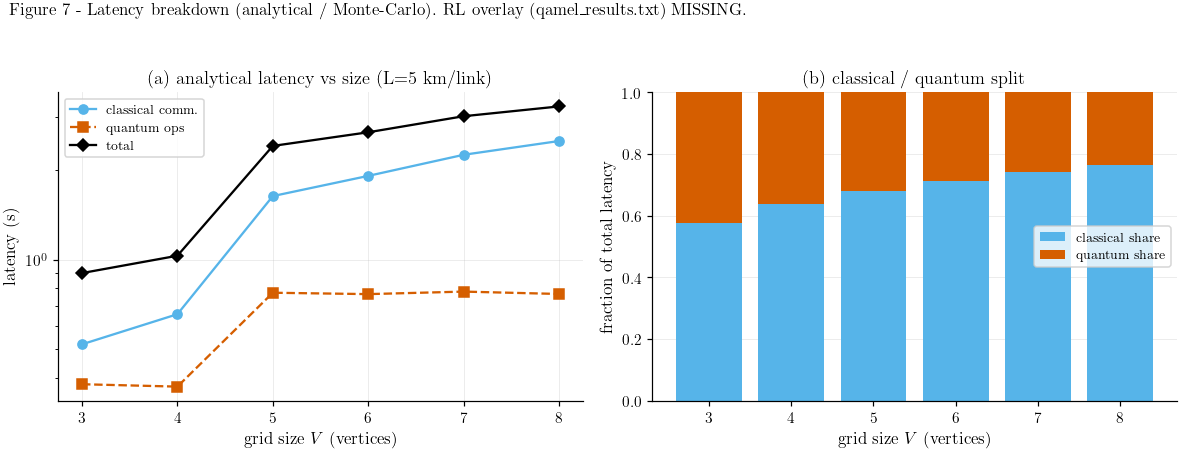

In [11]:
from analytical_solution.monte_carlo import monte_carlo

# --- physical constants (verbatim from calculate_ratio_and_latencies.ipynb) ---
Q_SWAP   = 0.7
K_FUSION = 0.5
def p_l(L):
    p_0 = 0.0018
    return p_0 * 10 ** ((-0.2 * L) / 10)
C_FIBRE = 299792.458 / 1.4585
T_ENT, T_SWAP, T_FUSION = 123e-6, 2157e-6, 300e-6
SIM_COUNT = 4000          # smaller than the notebook's 10000 to keep this fast & deterministic-ish
np.random.seed(SEED)

def classical_quantum(L, vertices, eps, sig, kap):
    classical = eps * (2 * vertices * (L / C_FIBRE) + (L / C_FIBRE)) + sig * (2 * (vertices - 1) * (L / C_FIBRE))
    quantum   = eps * T_ENT + sig * T_SWAP + kap * T_ENT
    return classical, quantum

L_FIXED = 5.0   # km per elementary link (representative; latency notebook sweeps L for fixed n)
vertices_range = [3, 4, 5, 6, 7, 8]

rows = []
for V in vertices_range:
    segments = V - 1
    p = p_l(L_FIXED)
    # monte_carlo's grid helper, called with `segments` exactly as the latency notebook does
    _, e_all, p_all, k_all = monte_carlo(segments, SIM_COUNT, SIM_COUNT, p, Q_SWAP, K_FUSION, ind=True)
    eps, sig, kap = np.mean(e_all), np.mean(p_all), np.mean(k_all)
    classical, quantum = classical_quantum(L_FIXED, V, eps, sig, kap)
    rows.append({"vertices": V, "classical": classical, "quantum": quantum,
                 "total": classical + quantum})
lat = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

ax = axes[0]
ax.plot(lat["vertices"], lat["classical"], "o-", color=OKABE_ITO["skyblue"], label="classical comm.")
ax.plot(lat["vertices"], lat["quantum"],  "s--", color=OKABE_ITO["vermillion"], label="quantum ops")
ax.plot(lat["vertices"], lat["total"],    "D-",  color=OKABE_ITO["black"], label="total")
ax.set_xlabel("grid size $V$ (vertices)"); ax.set_ylabel("latency (s)")
ax.set_yscale("log")
ax.set_title(f"(a) analytical latency vs size  (L={L_FIXED:g} km/link)")
ax.legend(fontsize=8.5)

ax = axes[1]
frac_c = lat["classical"] / lat["total"]
frac_q = lat["quantum"] / lat["total"]
ax.bar(lat["vertices"], frac_c, color=OKABE_ITO["skyblue"], label="classical share")
ax.bar(lat["vertices"], frac_q, bottom=frac_c, color=OKABE_ITO["vermillion"], label="quantum share")
ax.set_xlabel("grid size $V$ (vertices)"); ax.set_ylabel("fraction of total latency")
ax.set_ylim(0, 1); ax.set_title("(b) classical / quantum split")
ax.legend(fontsize=8.5, loc="center right")

fig.suptitle("Figure 7 - Latency breakdown (analytical / Monte-Carlo). "
             "RL overlay (qamel_results.txt) MISSING.", x=0.02, ha="left", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_fig(fig, "fig7_latency")
plt.show()

> **Blocked overlay — RL-derived latency.** The file
> `qamel/outputs/results/qamel_results.txt` (and `…_err.txt`) referenced by
> `notebooks/calculate_ratio_and_latencies.ipynb` / `notebooks/agent_latencies.py` does not exist
> in this checkout (it was written on a GPU machine under an absolute `S:/…` Windows path). Without
> it we cannot overlay the learned policy's measured `(ε, σ, κ)` counts on the analytical latency.
> To regenerate, fix the path bug in `notebooks/agent_latencies.py` (indentation at line ~34) and
> run it so it drives `run_evaluation` over the distance grid and writes
> `qamel/outputs/results/qamel_results.txt`.

## Figure status summary — publication-ready vs blocked

| Fig | Figure | Status | Blocker (if any) |
|-----|--------|--------|------------------|
| 1 | MDP schematic | **Ready** (first draft, to be hand-refined) | — |
| 2 | Learning curves | **Partial** | n=6 has no runs; n=5 single-seed, ≤1000-episode pilot |
| 3 | Sample efficiency | **Partial** | only local-pilot budgets (50–1000); no 10k–200k; no n=6 |
| 4 | Attempt dist. vs analytical | **Partial (centerpiece)** | RL policy under-trained (best greedy SR≈0.19); single seed |
| 5 | Policy vs baselines | **Partial** | tabular Q-table un-evaluated; single seed; budget-limited DQN |
| 6 | Ablation deltas | **Ready** | single seed (annotated); data complete & self-consistent |
| 7 | Latency | **Partial** | RL latency overlay file `qamel_results.txt` missing |

**To make the partials publication-ready, the missing data is:**
1. **Multi-seed runs** (≥3 seeds) for every study — currently only seed `12345`.
2. **n=6 runs** at the canonical budgets — none exist.
3. **Canonical budgets** `10k/50k/100k/200k` archived via `scripts/run_stage2_study.sh` —
   only local-pilot budgets exist, so the n=5 policy is under-trained (Figs 4/5 gaps are budget
   artifacts, not algorithmic ceilings).
4. **A tabular-Q evaluation summary** (run `scripts/evaluate_qamel.py` with the baseline obs mode
   on the cached Q-table) to fill the grey bar in Fig 5.
5. **The RL latency counts** `qamel/outputs/results/qamel_results.txt` for the Fig 7 overlay.

Every figure above was generated from real files; no variance, bands, or success numbers were
synthesised. Missing sources are drawn as labelled placeholders, not invented data.